# model_ver07: CNN と model_ver06 のアンサンブルノートブック

このノートブックでは、`model_ver05` の CNN 予測と `model_ver06` のベースライン最良予測を使って、OOF ベースでアンサンブル重みを決めます。  
モデル自体を再学習せず、保存済みの OOF / test 予測を組み合わせるため、試行が軽く、提出ファイルもすぐ作れます。

## このノートブックの狙い
- CNN と Ridge/PLS/SVR 系ベースラインの予測を比較する
- 単純平均と重み付き平均を OOF RMSE で評価する
- OOF で最も良かった重みを test 予測にも適用し、submission を保存する

## 入力ファイル
- `models/model_ver05_oof.csv`
- `models/model_ver05_test_pred.csv`
- `models/model_ver06_oof_sg_1deriv_ridge.csv`
- `models/model_ver06_test_pred_sg_1deriv_ridge.csv`

## 出力先
- モデル作成・分析に関与するファイル: `models/`
- 提出用ファイル: `submission/`


## 各関数の役割

- `CFG`  
  読み込む予測ファイル、出力先、重み探索幅をまとめて管理します。
- `rmse_score`  
  コンペ評価指標に合わせて RMSE を計算します。
- `load_oof_predictions`  
  各モデルの OOF 予測を `sample number` でそろえて結合します。
- `load_test_predictions`  
  各モデルの test 予測を `sample number` でそろえて結合します。
- `search_two_model_weight`  
  2モデルの重み付き平均を OOF RMSE で探索します。
- `save_ensemble_outputs`  
  アンサンブルの OOF、test 予測、重み設定、submission を保存します。


In [13]:
# ============================================================
# ライブラリのインポートと設定値の定義
# ============================================================
import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import mean_squared_error


class CFG:
    # バージョン名。出力ファイル名にも使う
    VER = 7

    # パス設定
    ROOT = Path('/workspace')
    DATA_PATH = ROOT / 'data' / 'raw'
    MODEL_PATH = ROOT / 'models'
    SUBMISSION_PATH = ROOT / 'submission'

    # コンペ設定
    target_col = '含水率'
    id_cols = ['sample number', 'species number', '樹種']

    # アンサンブル対象。oof_col / pred_col は各CSV内の予測列名
    model_configs = [
        {
            'name': 'model_ver05_cnn',
            'oof_path': MODEL_PATH / 'model_ver05_oof.csv',
            'test_path': MODEL_PATH / 'model_ver05_test_pred.csv',
            'oof_col': 'oof_pred',
            'pred_col': 'pred',
        },
        {
            'name': 'model_ver06_sg_1deriv_ridge',
            'oof_path': MODEL_PATH / 'model_ver06_oof_sg_1deriv_ridge.csv',
            'test_path': MODEL_PATH / 'model_ver06_test_pred_sg_1deriv_ridge.csv',
            'oof_col': 'oof_pred',
            'pred_col': 'pred',
        },
    ]

    # 0.00〜1.00 を 0.01 刻みで探索する。必要なら 0.001 刻みに広げる
    weight_grid = np.linspace(0.0, 1.0, 101)


CFG.MODEL_PATH.mkdir(parents=True, exist_ok=True)
CFG.SUBMISSION_PATH.mkdir(parents=True, exist_ok=True)


In [14]:
# ============================================================
# 評価関数と読み込み関数
# ============================================================
def rmse_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """RMSE を計算する関数。コンペの評価指標に合わせる。"""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def validate_input_files(model_configs: List[dict]) -> None:
    """アンサンブルに必要な予測ファイルが揃っているか確認する関数。"""
    missing_paths = []
    for config in model_configs:
        for key in ['oof_path', 'test_path']:
            if not config[key].exists():
                missing_paths.append(str(config[key]))

    if missing_paths:
        raise FileNotFoundError('必要な予測ファイルが見つかりません: ' + ', '.join(missing_paths))


def load_oof_predictions(model_configs: List[dict]) -> pd.DataFrame:
    """各モデルの OOF 予測を sample number でそろえて結合する関数。"""
    base_df = None

    for config in model_configs:
        pred_col = f"pred_{config['name']}"
        use_cols = CFG.id_cols + [CFG.target_col, config['oof_col']]
        model_df = pd.read_csv(config['oof_path'], usecols=use_cols)
        model_df = model_df.rename(columns={config['oof_col']: pred_col})

        if base_df is None:
            base_df = model_df
        else:
            merge_cols = CFG.id_cols + [CFG.target_col]
            base_df = base_df.merge(model_df, on=merge_cols, how='inner')

    return base_df


def load_test_predictions(model_configs: List[dict]) -> pd.DataFrame:
    """各モデルの test 予測を sample number でそろえて結合する関数。"""
    base_df = None

    for config in model_configs:
        pred_col = f"pred_{config['name']}"
        use_cols = CFG.id_cols + [config['pred_col']]
        model_df = pd.read_csv(config['test_path'], usecols=use_cols)
        model_df = model_df.rename(columns={config['pred_col']: pred_col})

        if base_df is None:
            base_df = model_df
        else:
            base_df = base_df.merge(model_df, on=CFG.id_cols, how='inner')

    return base_df


validate_input_files(CFG.model_configs)
oof_df = load_oof_predictions(CFG.model_configs)
test_pred_df = load_test_predictions(CFG.model_configs)
sample_submit_df = pd.read_csv(CFG.DATA_PATH / 'sample_submit.csv', header=None, encoding='cp932')

pred_cols = [f"pred_{config['name']}" for config in CFG.model_configs]
print(f'OOF shape: {oof_df.shape}')
print(f'test prediction shape: {test_pred_df.shape}')
print(f'prediction columns: {pred_cols}')
display(oof_df.head())


OOF shape: (1322, 6)
test prediction shape: (550, 5)
prediction columns: ['pred_model_ver05_cnn', 'pred_model_ver06_sg_1deriv_ridge']


,sample number,species number,樹種,含水率,pred_model_ver05_cnn,pred_model_ver06_sg_1deriv_ridge
0,1,1,イチョウ,216.129032,224.49355,204.95152
1,2,1,イチョウ,210.752688,219.10033,195.55006
2,3,1,イチョウ,205.913979,184.75279,199.30212
3,4,1,イチョウ,201.075269,178.19630,187.90482
4,5,1,イチョウ,196.236559,177.56264,201.45890


In [15]:
# ============================================================
# 各モデル単体と単純平均の確認
# ============================================================
y_true = oof_df[CFG.target_col].values
single_scores = []

for pred_col in pred_cols:
    score = rmse_score(y_true, oof_df[pred_col].values)
    single_scores.append({'name': pred_col.replace('pred_', ''), 'weight': None, 'rmse': score})

simple_average_oof = oof_df[pred_cols].mean(axis=1).values
simple_average_score = rmse_score(y_true, simple_average_oof)
single_scores.append({'name': 'simple_average', 'weight': 'equal', 'rmse': simple_average_score})

single_scores_df = pd.DataFrame(single_scores).sort_values('rmse').reset_index(drop=True)
display(single_scores_df)


,name,weight,rmse
0,simple_average,equal,7.644538
1,model_ver05_cnn,NaN,8.891665
2,model_ver06_sg_1deriv_ridge,NaN,10.271416


In [16]:
# ============================================================
# 2モデルの重み探索
# ============================================================
def search_two_model_weight(
    y_true: np.ndarray,
    pred_a: np.ndarray,
    pred_b: np.ndarray,
    weight_grid: np.ndarray,
) -> pd.DataFrame:
    """pred_a の重みを探索し、pred_b との重み付き平均 RMSE を返す関数。"""
    rows = []
    for weight_a in weight_grid:
        weight_b = 1.0 - weight_a
        ensemble_pred = weight_a * pred_a + weight_b * pred_b
        rows.append(
            {
                'weight_model_a': float(weight_a),
                'weight_model_b': float(weight_b),
                'rmse': rmse_score(y_true, ensemble_pred),
            }
        )
    return pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)


if len(pred_cols) != 2:
    raise ValueError('model_ver07 は 2 モデルのアンサンブルを想定しています。')

model_a_col, model_b_col = pred_cols
weight_results_df = search_two_model_weight(
    y_true=y_true,
    pred_a=oof_df[model_a_col].values,
    pred_b=oof_df[model_b_col].values,
    weight_grid=CFG.weight_grid,
)

best_weight = weight_results_df.iloc[0]
best_weight_a = float(best_weight['weight_model_a'])
best_weight_b = float(best_weight['weight_model_b'])
best_rmse = float(best_weight['rmse'])

print(f'{model_a_col} weight: {best_weight_a:.2f}')
print(f'{model_b_col} weight: {best_weight_b:.2f}')
print(f'Best ensemble OOF RMSE: {best_rmse:.4f}')
display(weight_results_df.head(10))


pred_model_ver05_cnn weight: 0.60
pred_model_ver06_sg_1deriv_ridge weight: 0.40
Best ensemble OOF RMSE: 7.5597


,weight_model_a,weight_model_b,rmse
0,0.60,0.40,7.559672
1,0.59,0.41,7.560148
2,0.61,0.39,7.560987
3,0.58,0.42,7.562415
4,0.62,0.38,7.564091
5,0.57,0.43,7.566470
6,0.63,0.37,7.568983
7,0.56,0.44,7.572310
8,0.64,0.36,7.575659
9,0.55,0.45,7.579932


In [17]:
# ============================================================
# アンサンブル予測の作成と保存
# ============================================================
def save_submission(predictions: np.ndarray, save_name: str) -> Path:
    """サンプル提出ファイルの形式で予測値を書き出す関数。"""
    submit_df = sample_submit_df.copy()
    submit_df[1] = predictions
    save_path = CFG.SUBMISSION_PATH / save_name
    submit_df.to_csv(save_path, header=False, index=False)
    return save_path


def save_ensemble_outputs() -> Tuple[pd.DataFrame, pd.DataFrame, Path]:
    """最良重みの OOF / test 予測、探索結果、設定、submission を保存する関数。"""
    ensemble_oof = (
        best_weight_a * oof_df[model_a_col].values
        + best_weight_b * oof_df[model_b_col].values
    )
    ensemble_test = (
        best_weight_a * test_pred_df[model_a_col].values
        + best_weight_b * test_pred_df[model_b_col].values
    )

    oof_output_df = oof_df[CFG.id_cols + [CFG.target_col]].copy()
    oof_output_df['oof_pred'] = ensemble_oof
    oof_output_df.to_csv(CFG.MODEL_PATH / 'model_ver07_oof_ensemble.csv', index=False, encoding='utf-8-sig')

    test_output_df = test_pred_df[CFG.id_cols].copy()
    test_output_df['pred'] = ensemble_test
    test_output_df.to_csv(CFG.MODEL_PATH / 'model_ver07_test_pred_ensemble.csv', index=False, encoding='utf-8-sig')

    weight_results_df.to_csv(CFG.MODEL_PATH / 'model_ver07_ensemble_weight_results.csv', index=False, encoding='utf-8-sig')
    single_scores_df.to_csv(CFG.MODEL_PATH / 'model_ver07_base_scores.csv', index=False, encoding='utf-8-sig')

    ensemble_config = {
        'version': CFG.VER,
        'model_a': model_a_col.replace('pred_', ''),
        'model_b': model_b_col.replace('pred_', ''),
        'weight_model_a': best_weight_a,
        'weight_model_b': best_weight_b,
        'oof_rmse': best_rmse,
        'input_files': [
            {
                'name': config['name'],
                'oof_path': str(config['oof_path']),
                'test_path': str(config['test_path']),
            }
            for config in CFG.model_configs
        ],
    }
    config_path = CFG.MODEL_PATH / 'model_ver07_ensemble_config.json'
    config_path.write_text(json.dumps(ensemble_config, ensure_ascii=False, indent=2), encoding='utf-8')

    submission_path = save_submission(ensemble_test, 'model_ver07_submission.csv')
    return oof_output_df, test_output_df, submission_path


oof_output_df, test_output_df, submission_path = save_ensemble_outputs()
print(f'OOF RMSE: {rmse_score(oof_output_df[CFG.target_col].values, oof_output_df["oof_pred"].values):.4f}')
print(f'提出ファイル保存先: {submission_path}')


OOF RMSE: 7.5597
提出ファイル保存先: /workspace/submission/model_ver07_submission.csv


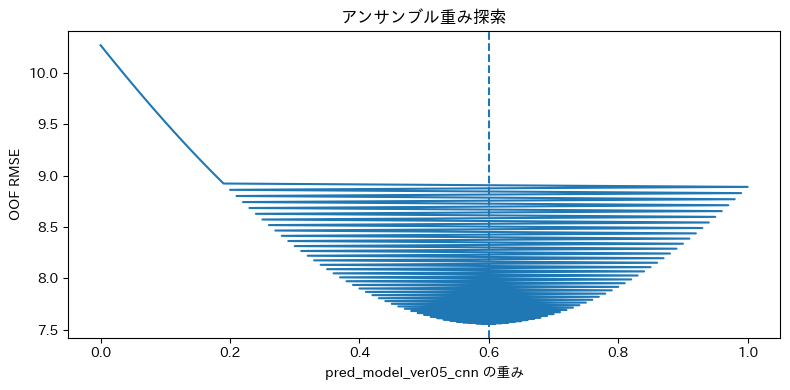

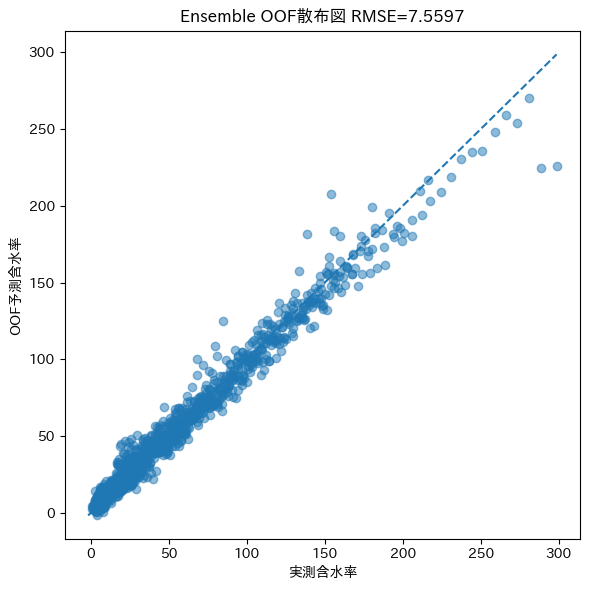

In [18]:
# ============================================================
# 結果の可視化
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(weight_results_df['weight_model_a'], weight_results_df['rmse'])
plt.axvline(best_weight_a, linestyle='--')
plt.xlabel(f'{model_a_col} の重み')
plt.ylabel('OOF RMSE')
plt.title('アンサンブル重み探索')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(oof_output_df[CFG.target_col], oof_output_df['oof_pred'], alpha=0.5)
line_min = min(oof_output_df[CFG.target_col].min(), oof_output_df['oof_pred'].min())
line_max = max(oof_output_df[CFG.target_col].max(), oof_output_df['oof_pred'].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
plt.xlabel('実測含水率')
plt.ylabel('OOF予測含水率')
plt.title(f'Ensemble OOF散布図 RMSE={best_rmse:.4f}')
plt.tight_layout()
plt.show()


## 補足

- `model_ver07` は学習済みモデルを再学習せず、保存済み予測値を使うアンサンブル用ノートブックです。
- OOF で探索した重みを test 側にもそのまま適用します。
- 2モデルの誤差傾向が違うほど、単体モデルより伸びる可能性があります。
- 次に発展させるなら、`model_ver08` で複数バージョンの予測を追加し、Ridge メタモデルや制約付き最適化で stacking に近づけるのが自然です。
